# KRX-PBR vs OpenDART-BE — B/M 일치도 검증 (5a 스파이크)

**목적:** 2015+ 겹구간에서 KRX PBR로 만든 B/M과 OpenDART 장부가(BE)로 만든 B/M이 얼마나 일치하는지 측정.
충분히 일치하면 → KRX PBR을 2003까지 확장해 v0.1 표본으로 써도 된다는 실증 근거.

**전제:**
- 프로젝트 루트 `.env`에 `KRX_ID`/`KRX_PW`/`DART_API_KEY` 존재.
- 설치: `pip install OpenDartReader` (pykrx·python-dotenv·pandas·numpy·matplotlib는 기존 환경 가정).
- **이 노트북은 커널 재시작 후 처음부터 순서대로 실행** (pykrx가 import 시 KRX 로그인을 수행하므로 `load_dotenv()`가 먼저 와야 함).

**정렬 규칙:** FF 6월 리밸 관행 — 6월 시점 시가 ↔ 직전 12월 결산 장부가. 아래 예시는 2019-06 시가/PBR ↔ FY2018 연차 BE.

In [1]:
# [1] .env 로드는 반드시 pykrx import보다 먼저
import os, time
from dotenv import load_dotenv
load_dotenv()                      # 프로젝트 루트의 .env (KRX_ID/KRX_PW/DART_API_KEY)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import OpenDartReader
from pykrx import stock            # load_dotenv() 이후에 import

DART_KEY = os.environ.get("DART_API_KEY")
assert DART_KEY, "DART_API_KEY가 .env에 없습니다. .env에 DART_API_KEY=<40자키> 추가 후 커널 재시작."
dart = OpenDartReader(DART_KEY)
print("OpenDartReader 준비 완료 · 키 길이:", len(DART_KEY))

KRX 로그인 시도...
  로그인 ID: taeyoon3684
KRX 로그인 완료.
  로그인 시간: 2026-07-01 01:57:33
  만료 시간: 2026-07-01 02:57:33
OpenDartReader 준비 완료 · 키 길이: 40


## 파라미터

- `DATE` = KRX 시장 기준일 (거래일이어야 함). FF 관행상 6월 말 근처.
- `FY` = DART 사업연도. `DATE` 시점에 이미 공시된 직전 연차여야 함 (예: 2019-06이면 FY2018, ~2019-03 제출).
- 다른 연도(예: 2021-06 / FY2020)로도 한 번 더 돌려 **시점 안정성**을 확인할 것 — 단일 횡단면으로 결론내지 말 것.

In [2]:
# [2] 파라미터 + KRX 쪽 풀 (시총·PBR)
DATE   = "20190628"    # KRX 거래일 (직전 12월 결산 반영 시점)
FY     = "2018"        # DART 사업연도 (DATE 시점에 가용한 직전 연차)
MARKET = "KOSPI"

fund  = stock.get_market_fundamental(DATE, market=MARKET)   # BPS, PER, PBR, EPS, DIV, DPS
capdf = stock.get_market_cap(DATE, market=MARKET)           # 시가총액, 상장주식수 등

krx = fund[["BPS", "PBR"]].join(capdf[["시가총액", "상장주식수"]], how="inner")
krx = krx[(krx["PBR"] > 0) & (krx["시가총액"] > 0)].copy()
krx["BM_krx"]        = 1.0 / krx["PBR"]                      # KRX B/M = 1/PBR
krx["BE_krx_implied"]= krx["BPS"] * krx["상장주식수"]        # KRX 내재 장부가(보통주 기준, 진단용)
print(f"{DATE} {MARKET} · PBR>0 종목수: {len(krx)}")
krx.head()

20190628 KOSPI · PBR>0 종목수: 768


,BPS,PBR,시가총액,상장주식수,BM_krx,BE_krx_implied
티커,,,,,,
095570,7231,0.75,252372170050,46822295,1.333333,338572015145
068400,11150,0.94,231428835000,22146300,1.063830,246931245000
006840,63797,0.70,588854086450,13247561,1.428571,845154649117
027410,15719,0.47,705731924600,95369179,2.127660,1499108124701
282330,30182,6.99,3646904166000,17283906,0.143062,521662850892


## 표본

검증 스파이크라 전수 불필요. **B/M 5분위 층화 표본**으로 가치 극단(지주사 오염이 사는 곳)까지 커버.
`N_PER_Q`를 키우면 표본↑ = DART 호출수↑ (분위당 n).

In [3]:
# [3] B/M 5분위 층화 표본
N_PER_Q = 30                       # 분위당 표본수 → 총 ~150. 호출수 = 표본수.
krx["Qsamp"] = pd.qcut(krx["BM_krx"], 5, labels=False)
sample = krx.groupby("Qsamp", group_keys=False).sample(n=N_PER_Q, random_state=42)
print("표본 종목수:", len(sample),
      "| 분위 분포:", sample["Qsamp"].value_counts().sort_index().tolist())

표본 종목수: 150 | 분위 분포: [30, 30, 30, 30, 30]


## OpenDART 장부가(BE) 추출

우선순위: **지배주주지분**(`ifrs-full_EquityAttributableToOwnersOfParent`, KRX BPS 기준과 일치) → 없으면 자본총계.
연결(CFS) 우선, 없으면 별도(OFS). 금융주는 구조가 달라 누락될 수 있음 — FF도 제외 대상이니 무방.

In [4]:
# [4] BE 추출 함수 + 표본 루프
def to_num(x):
    s = str(x).replace(",", "").replace(" ", "").strip()
    if s in ("", "-", "--", "nan", "None"):
        return np.nan
    neg = s.startswith("(") and s.endswith(")")
    s = s.strip("()")
    try:
        v = float(s)
    except ValueError:
        return np.nan
    return -v if neg else v

def extract_be(stock_code, year):
    """지배주주지분 우선, 자본총계 폴백. (값, fs_div, 출처태그) 반환."""
    for fs_div in ("CFS", "OFS"):
        try:
            df = dart.finstate_all(stock_code, year, reprt_code="11011", fs_div=fs_div)
        except Exception:
            df = None
        if df is None or len(df) == 0:
            continue
        bs = df[df["sj_div"] == "BS"].copy()
        if bs.empty:
            continue
        bs["amt"] = bs["thstrm_amount"].map(to_num)
        nm  = bs["account_nm"].astype(str)
        aid = bs["account_id"].astype(str)
        # 1) 지배주주지분 (IFRS 태그)
        c = bs[aid == "ifrs-full_EquityAttributableToOwnersOfParent"]
        if len(c) and pd.notna(c["amt"].iloc[0]):
            return c["amt"].iloc[0], fs_div, "parent_id"
        # 2) 지배주주지분 (계정명)
        c = bs[nm.str.contains("지배") & nm.str.contains("지분") & ~nm.str.contains("비지배")]
        if len(c) and pd.notna(c["amt"].iloc[0]):
            return c["amt"].iloc[0], fs_div, "parent_nm"
        # 3) 자본총계 (IFRS 태그)
        c = bs[aid == "ifrs-full_Equity"]
        if len(c) and pd.notna(c["amt"].iloc[0]):
            return c["amt"].iloc[0], fs_div, "total_id"
        # 4) 자본총계 (계정명)
        c = bs[nm.str.replace(" ", "").eq("자본총계")]
        if len(c) and pd.notna(c["amt"].iloc[0]):
            return c["amt"].iloc[0], fs_div, "total_nm"
    return np.nan, None, None

rows, codes = [], list(sample.index)
for i, code in enumerate(codes, 1):
    be, fsdiv, how = extract_be(code, FY)
    rows.append({"ticker": code, "BE_dart": be, "fs_div": fsdiv, "how": how})
    if i % 20 == 0 or i == len(codes):
        print(f"  {i}/{len(codes)} 처리...")
    time.sleep(0.05)               # 도의적 호출 간격
be_df = pd.DataFrame(rows).set_index("ticker")
print("BE 추출 성공:", int(be_df["BE_dart"].notna().sum()), "/", len(be_df))
be_df["how"].value_counts(dropna=False)

reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표)'
reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표)'
{'status': '013', 'message': '조회된 데이타가 없습니다.'}
reprt_code='11011', fs_div='OFS' (사업보고서, 별도(개별)제무제표)'
reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표)'
reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표)'
{'status': '013', 'message': '조회된 데이타가 없습니다.'}
reprt_code='11011', fs_div='OFS' (사업보고서, 별도(개별)제무제표)'
reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표)'
{'status': '013', 'message': '조회된 데이타가 없습니다.'}
reprt_code='11011', fs_div='OFS' (사업보고서, 별도(개별)제무제표)'
reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표)'
{'status': '013', 'message': '조회된 데이타가 없습니다.'}
reprt_code='11011', fs_div='OFS' (사업보고서, 별도(개별)제무제표)'
reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표)'
reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표)'
{'status': '013', 'message': '조회된 데이타가 없습니다.'}
reprt_code='11011', fs_div='OFS' (사업보고서, 별도(개별)제무제표)'
reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무제표)'
reprt_code='11011', fs_div='CFS' (사업보고서, 연결제무

how
total_nm     105
parent_nm     35
None           8
parent_id      2
Name: count, dtype: int64

## 병합 + 비교 지표

- **Spearman 순위상관** — FF 5×5 소트가 같은 방향으로 종목을 정렬하는가.
- **로그 B/M Pearson** — 수준 일치도.
- **5분위 동일배정 / ±1분위 이내** — 소트 재현성의 직접 척도.
- **장부가 상대편차 중앙값** — KRX 내재 BE vs DART BE 괴리(우선주·결산시점·연결범위에서 발생).

In [5]:
# [5] 병합 + 지표
m = sample.join(be_df[["BE_dart", "fs_div", "how"]], how="left")
m = m[m["BE_dart"].notna() & (m["BE_dart"] > 0)].copy()      # 자본잠식(음수)은 비교서 제외
m["BM_dart"]    = m["BE_dart"] / m["시가총액"]
m["reldiff_BE"] = (m["BE_dart"] - m["BE_krx_implied"]) / m["BE_krx_implied"]
m["name"]       = [stock.get_market_ticker_name(t) for t in m.index]

rho = m["BM_krx"].corr(m["BM_dart"], method="spearman")
lr  = np.log(m["BM_krx"]).corr(np.log(m["BM_dart"]))         # 로그 B/M 피어슨
m["Qk"] = pd.qcut(m["BM_krx"], 5, labels=False)
m["Qd"] = pd.qcut(m["BM_dart"], 5, labels=False)
same_q  = (m["Qk"] == m["Qd"]).mean()
within1 = (abs(m["Qk"] - m["Qd"]) <= 1).mean()
med_abs = m["reldiff_BE"].abs().median()

print(f"비교 표본(자본>0): {len(m)}")
print(f"[순위상관]   Spearman rho = {rho:.3f}")
print(f"[로그 B/M]   Pearson  r   = {lr:.3f}")
print(f"[5분위 동일배정] {same_q:.1%}   | [±1분위 이내] {within1:.1%}")
print(f"[장부가 |상대편차| 중앙값] {med_abs:.1%}")

비교 표본(자본>0): 142
[순위상관]   Spearman rho = 0.928
[로그 B/M]   Pearson  r   = 0.873
[5분위 동일배정] 88.0%   | [±1분위 이내] 97.9%
[장부가 |상대편차| 중앙값] 0.3%


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


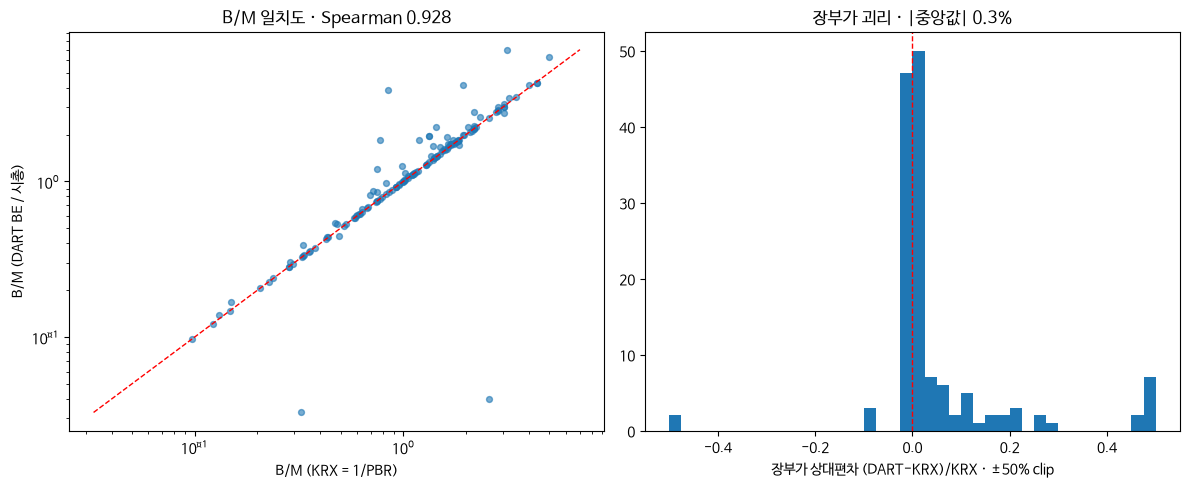

장부가 괴리 큰 상위 12 (우선주·결산시점·연결범위 의심):


,name,PBR,BM_krx,BM_dart,BE_dart,BE_krx_implied,reldiff_BE,fs_div,how
티커,,,,,,,,,
000150,두산,1.18,0.847458,3.845450,7.048438e+12,1552208385016,3.540910,CFS,total_nm
016450,한세예스24홀딩스,1.29,0.775194,1.845093,6.177373e+11,260440000000,1.371899,CFS,total_nm
006200,한국전자홀딩스,0.32,3.125000,7.019070,2.641257e+11,118177918400,1.234983,CFS,total_nm
084690,대상홀딩스,0.52,1.923077,4.164196,1.094780e+12,509800109964,1.147469,CFS,total_nm
071320,지역난방공사,0.39,2.564103,0.040249,2.428055e+10,1560154702792,-0.984437,CFS,parent_nm
016380,KG스틸,3.09,0.323625,0.032785,6.089187e+09,60185867040,-0.898827,CFS,parent_id
034310,NICE,1.33,0.751880,1.209413,1.040008e+12,644302158400,0.614162,CFS,total_nm
008870,금비,0.70,1.428571,2.251472,1.562522e+11,98534000000,0.585769,CFS,total_nm
007540,샘표,0.84,1.190476,1.856434,2.330357e+11,150024734400,0.553315,CFS,total_nm


In [6]:
# [6] 산점도 + 괴리 큰 종목
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
lo = min(m["BM_krx"].min(), m["BM_dart"].min())
hi = max(m["BM_krx"].max(), m["BM_dart"].max())
ax[0].scatter(m["BM_krx"], m["BM_dart"], s=18, alpha=0.6)
ax[0].plot([lo, hi], [lo, hi], "r--", lw=1)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("B/M (KRX = 1/PBR)"); ax[0].set_ylabel("B/M (DART BE / 시총)")
ax[0].set_title(f"B/M 일치도 · Spearman {rho:.3f}")

ax[1].hist(m["reldiff_BE"].clip(-0.5, 0.5), bins=40)
ax[1].axvline(0, color="r", ls="--", lw=1)
ax[1].set_xlabel("장부가 상대편차 (DART-KRX)/KRX · ±50% clip")
ax[1].set_title(f"장부가 괴리 · |중앙값| {med_abs:.1%}")
plt.tight_layout(); plt.show()

print("장부가 괴리 큰 상위 12 (우선주·결산시점·연결범위 의심):")
cols = ["name","PBR","BM_krx","BM_dart","BE_dart","BE_krx_implied","reldiff_BE","fs_div","how"]
m.reindex(m["reldiff_BE"].abs().sort_values(ascending=False).index)[cols].head(12)

## 판정 가이드

제안 합격선 (절대 기준 아님 — 직접 판단):

- Spearman rho ≥ **0.95**, 5분위 동일배정 ≥ **70%**, ±1분위 이내 ≥ **95%**, 장부가 |상대편차| 중앙값 ≤ **5%**
  → KRX PBR을 2003까지 확장해 v0.1 표본으로 쓰는 것을 정당화.

**괴리 큰 종목 패턴 확인:**
- 우선주 발행사 → KRX BPS 분모(보통주+우선주)와 DART 지배주주지분 기준 차이. 골드판에서 BE−우선주로 보정 대상.
- 비12월 결산사 → 결산시점 불일치. D2 매핑 규율에서 별도 처리.
- 연결범위 차이(`fs_div`=OFS로 폴백된 종목) → 별도재무제표만 있는 소형주.

**다음:** `DATE`/`FY`를 다른 연도(예: 2021-06 / FY2020)로 바꿔 한 번 더 → 일치도가 시점에 안정적인지 확인 후 결론.